# MIMIC-CXR clean dataset

This notebook shows how to read the clean MIMIC-CXR dataset, inspect labels, and display a few chest X-ray images.

Main task: multi-label chest X-ray classification. Optional extension: use the `report` text.

-----

# Dataset MIMIC-CXR

Este notebook muestra cómo leer el dataset limpio MIMIC-CXR, inspeccionar las etiquetas y visualizar algunas radiografías de tórax.

Tarea principal: clasificación multi-etiqueta de radiografías de tórax. Extensión opcional: usar el texto del reporte radiológico disponible en la columna `report`.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

# Reemplazar con tu ruta al dataset / Replace with your path to the dataset
DATASET_DIR = Path("PATH-TO-DATASET/MIMIC-CXR")
DATASET_DIR = Path(os.environ["SCRATCH"]) / "datasets" / "datatondatasets" / "MIMIC-CXR"

ROOT = DATASET_DIR
print("DATASET_DIR =", DATASET_DIR)

def show_image(path, title=""):
    path = Path(path)
    if not path.exists():
        print("Missing image:", path)
        return
    image = Image.open(path)
    plt.figure(figsize=(4, 4))
    plt.imshow(image, cmap="gray")
    plt.axis("off")
    plt.title(title)
    plt.show()

ROOT


DATASET_DIR = /lustre/fsn1/projects/rech/dtn/uap38od/datasets/datatondatasets/MIMIC-CXR


PosixPath('/lustre/fsn1/projects/rech/dtn/uap38od/datasets/datatondatasets/MIMIC-CXR')

In [2]:
train = pd.read_csv(ROOT / "train.csv")
valid = pd.read_csv(ROOT / "valid.csv")
test = pd.read_csv(ROOT / "test.csv")
print("train", train.shape)
print("valid", valid.shape)
print("test", test.shape)
train.head()


train (101138, 37)
valid (14216, 37)
test (28545, 37)


,image,dicom_id,subject_id,study_id,PerformedProcedureStepDescription,split,ViewPosition,Rows,Columns,StudyDate,...,Support Devices,race,sex,age,anchor_year,anchor_year_group,dod,race_label,sex_label,report
0,s51321189_d85c9f15-f0f84927-761f30e0-51c2d319-...,d85c9f15-f0f84927-761f30e0-51c2d319-f2d917f0,19702416,51321189,CHEST (PORTABLE AP),train,AP,3056,2544,21680821,...,NaN,White,Male,91.0,2168,2011 - 2013,2168-11-01,0,0,FINAL REPORT\...
1,s51292704_0024603b-12db30e2-ab32c9cb-dae5a3fc-...,0024603b-12db30e2-ab32c9cb-dae5a3fc-b2c598b4,13339704,51292704,CHEST (PORTABLE AP),train,AP,2544,3056,21360418,...,1.0,Black,Male,68.0,2133,2011 - 2013,NaN,2,0,FINAL REPORT\...
2,s54048859_8a4aaaee-55fcf98f-a036a8e7-da71eed1-...,8a4aaaee-55fcf98f-a036a8e7-da71eed1-4d7bf032,12668169,54048859,CHEST (PORTABLE AP),train,AP,2820,2539,21560819,...,1.0,White,Male,54.0,2156,2011 - 2013,2156-08-19,0,0,FINAL REPORT\...
3,s58144222_9886b0fe-9121c65e-c8d74649-4b88c530-...,9886b0fe-9121c65e-c8d74649-4b88c530-9b3943fb,10309415,58144222,CHEST (PORTABLE AP),train,AP,2544,3056,21140603,...,NaN,White,Male,88.0,2114,2014 - 2016,NaN,0,0,FINAL REPORT\...
4,s59315061_61b65859-4e25d250-d3faadc7-0fda22dd-...,61b65859-4e25d250-d3faadc7-0fda22dd-14abe901,19504029,59315061,CHEST (PA AND LAT),train,PA,3056,2544,21780421,...,NaN,Black,Female,54.0,2178,2011 - 2013,NaN,2,1,FINAL REPORT\...


In [3]:
print("Columns/Columnas:")
for column in train.columns:
    print("-", column)


Columns/Columnas:
- image
- dicom_id
- subject_id
- study_id
- PerformedProcedureStepDescription
- split
- ViewPosition
- Rows
- Columns
- StudyDate
- StudyTime
- ProcedureCodeSequence_CodeMeaning
- ViewCodeSequence_CodeMeaning
- PatientOrientationCodeSequence_CodeMeaning
- Atelectasis
- Cardiomegaly
- Consolidation
- Edema
- Enlarged Cardiomediastinum
- Fracture
- Lung Lesion
- Lung Opacity
- No Finding
- Pleural Effusion
- Pleural Other
- Pneumonia
- Pneumothorax
- Support Devices
- race
- sex
- age
- anchor_year
- anchor_year_group
- dod
- race_label
- sex_label
- report


In [4]:
label_cols = [
    "Atelectasis", "Cardiomegaly", "Consolidation", "Edema",
    "Enlarged Cardiomediastinum", "Fracture", "Lung Lesion", "Lung Opacity",
    "No Finding", "Pleural Effusion", "Pleural Other", "Pneumonia",
    "Pneumothorax", "Support Devices",
]
label_summary = train[label_cols].apply(lambda s: s.value_counts(dropna=False)).T.fillna(0).astype(int)
label_summary


,-1.0,0.0,1.0,NaN
Atelectasis,0,5157,22703,73278
Cardiomegaly,0,9336,21636,70166
Consolidation,0,4928,5453,90757
Edema,0,16481,13230,71427
Enlarged Cardiomediastinum,0,6273,3495,91370
Fracture,0,415,2136,98587
Lung Lesion,0,732,3047,97359
Lung Opacity,0,2497,25252,73389
No Finding,0,0,33217,67921
Pleural Effusion,0,13502,27116,60520


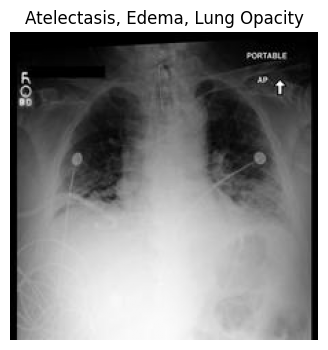

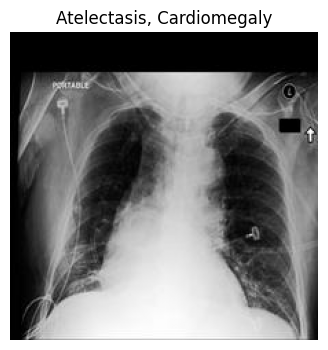

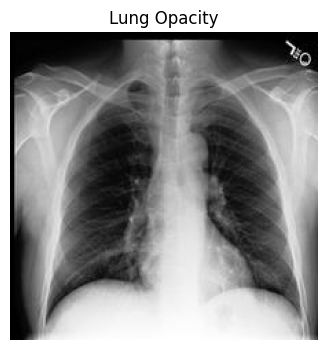

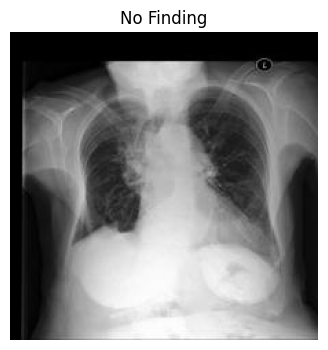

In [5]:
sample = train.sample(min(4, len(train)), random_state=1)
for _, row in sample.iterrows():
    positives = [label for label in label_cols if row.get(label) == 1 or row.get(label) == 1.0]
    title = ", ".join(positives[:3]) if positives else "No positive label shown"
    show_image(ROOT / "images" / row["image"], title=title)


In [6]:
row = train.iloc[0]
print("Image/Imágen:", row["image"])
print("Report preview / Vista previa del reporte:\n")
print(str(row.get("report", ""))[:1500])


Image/Imagen: s51321189_d85c9f15-f0f84927-761f30e0-51c2d319-f2d917f0.jpg
Report preview / Vista previa del reporte:

                                 FINAL REPORT
 CHEST RADIOGRAPH
 
 HISTORY:  Hypotension and altered mental status.
 
 COMPARISONS:  None.
 
 TECHNIQUE:  Chest, AP supine portable.
 
 FINDINGS:  There is a central venous catheter terminating at the cavoatrial
 junction, inserted via a right subclavian approach.  The heart is
 mild-to-moderately enlarged with a globular configuration.  The aortic arch is
 calcified.  The aortopulmonary window is slightly prominent suggesting
 possible enlargement of the main pulmonary artery.  Central pulmonary arteries
 are also mildly enlarged.  There is an asymmetric left paramedian opacity with
 upward tenting, perhaps a form of scarring.  Bilateral perihilar fullness
 suggests mild superimposed pulmonary congestion, however.  A moderate
 left-sided pleural effusion is also noted.  Associated parenchymal opacity is
 suspected, probabl